In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from scipy.interpolate import make_smoothing_spline


In [41]:
repo_folder = Path('../../..')
data_folder  = repo_folder / 'data'/ 'this_project' / '6_transporterKO'
metabolomics_folder = data_folder / 'D_big_screen'


In [42]:
median_fn = metabolomics_folder / 'G_median_z_scores_TIC_norm.csv'
df_data = pd.read_csv(median_fn, index_col=0)
df_data.rename(columns={'Z-score median': 'Median Z-score'}, inplace=True)

ionMz_annotation_fn = metabolomics_folder / 'H_ionMz_annotation.csv'
df_ionMz = pd.read_csv(ionMz_annotation_fn, index_col=0)

sample_metadata_fn = metabolomics_folder / 'I_sample_metadata.csv'
df_sample_metadata = pd.read_csv(sample_metadata_fn, index_col=0)

In [43]:
df_w_mz = df_data.merge(df_ionMz, on='ionMz', how='left')

In [44]:
df = df_w_mz.merge(df_sample_metadata, on=['Batch-Tube', 'Timepoint'], how='left')

# Plot

In [45]:
xval = 'Hours'
yval = 'Median Z-score'
ystd  = 'Z-score std'

In [46]:
df_data

,Batch-Tube,Timepoint,ionMz,Median Z-score,Z-score std
0,1-0A,1.0,57.0346,1.289937,0.291521
1,1-0A,1.0,59.0135,0.493675,0.445569
2,1-0A,1.0,71.0141,1.188120,0.116419
3,1-0A,1.0,72.0093,0.766767,0.861986
4,1-0A,1.0,72.9932,-0.011414,0.837190
...,...,...,...,...,...
663629,5-9C,10.0,835.0407,2.218702,0.234447
663630,5-9C,10.0,863.2971,1.883940,0.030993
663631,5-9C,10.0,864.1473,1.264271,0.451270
663632,5-9C,10.0,974.2935,0.426014,0.684794


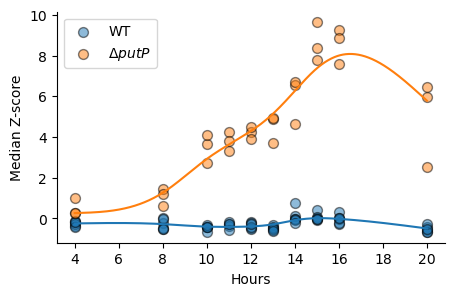

In [51]:
strains = ['putP', 'WT']
metabolite = 'Proline'

batch = df.loc[df.Strain==strains[0], 'Batch'].values[0]
idx = df.Strain.isin(strains)&(df.Metabolite==metabolite)&(df.Batch.isin([batch]))

# Get the data for each strain
data = df.loc[idx].copy()

# Make sure there are no duplicated x-values at all
is_duplicated = data[xval].duplicated()
if np.any(is_duplicated):
    # Add tiny random noise to the x-values to break ties
    data.loc[is_duplicated, xval] += np.random.normal(0, 1e-3, size=is_duplicated.sum())

data.sort_values(by = xval, inplace=True)

# Separate by strain
strain1, strain2 = strains
x1 = data.loc[data['Strain'] == strain1, xval].values
y1 = data.loc[data['Strain'] == strain1, yval].values
y1_std= data.loc[data['Strain'] == strain1, ystd].values#**2
x2 = data.loc[data['Strain'] == strain2, xval].values
y2 = data.loc[data['Strain'] == strain2, yval].values
y2_std= data.loc[data['Strain'] == strain2, ystd].values#**2

# Define common x grid (e.g., union or intersection)
x_common = np.linspace(max(x1.min(), x2.min()), min(x1.max(), x2.max()), 1000, endpoint=True)

# Spline interpolation
# # Doesn't work with exactly same x-values (hours)
# spline1 = make_splrep(x1, y1, s = np.std(y1), k = 3)
# spline2 = make_splrep(x2, y2,s = np.std(y2), k = 3)

spline5 = make_smoothing_spline(x1, y1, w = 1/y1_std, lam = 10)#, lam =1)
# spline5B = make_smoothing_spline(x1, y1, lam = 10)#, lam =1)

spline6 = make_smoothing_spline(x2, y2, w=1/y2_std, lam = 10)#, lam =1)
# spline6B = make_smoothing_spline(x2, y2, lam = 10)#, lam =1)

# y1_spline = spline1(x_common)
# y2_spline = spline2(x_common)

# Plot
plt.figure(figsize=(5,3))
# plt.plot(x_common, y1_spline, label=strain1 + ' (splrep)')
# plt.plot(x_common, y2_spline, label=strain2 + ' (splrep)')
plt.plot(x_common, spline5(x_common), c = 'C1')#, label=strain1 + ' (fit)')
# plt.plot(x_common, spline5B(x_common), label=strain1 + 'B (smoothing)')
plt.plot(x_common, spline6(x_common), c = 'C0')#, label=strain2 + ' (fit)')
# plt.plot(x_common, spline6B(x_common), label=strain2 + 'B (smoothing)')

plt.scatter(x2, y2, label=f'{strain2}', alpha=0.5, edgecolors='k', s=50, c = 'C0')
plt.scatter(x1, y1, label=f'Δ${strain1}$', alpha=0.5, edgecolors='k', s=50, c = 'C1')
sns.despine()
plt.xlabel(xval)
plt.ylabel(yval)
plt.legend(loc = 2)
# plt.title(f'Spline-interpolated time series for {m}')
# plt.savefig(figure_folder / f'spline_{m}_{strain1}_vs_{strain2}_{xval}.png', dpi = 300, bbox_inches = 'tight')
# plt.savefig(figure_folder / f'spline_{m}_{strain1}_vs_{strain2}_{xval}.pdf', dpi = 300, bbox_inches = 'tight')
plt.show()